# PyTorch workflow

Let's explore end to end workflow

In [1]:
what_were_convering = {1: "data (prepare and load)",
                       2: "build model",
                       3: "fitting the model to data (training)",
                       4: "making prediction",
                       5: "saving and loading a model"}
what_were_convering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making prediction',
 5: 'saving and loading a model'}

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.8.0+cu126'

## 1. Data preparing and loading
* Data can be anything (sheet, sql, nosql, images, vids, audio, dna)
* Machine learning is a game of two parts. get numerical representation -> learn paterns

Use linear ligression formula

In [3]:
# Create known params
w = 0.7
b = 0.3

start = 0
end = 1
step = 0.02
X= torch.arange(start,end,step)
# torch.manual_seed(0)
# noise = torch.randn(len(X))
y = w * X ** b

X[40:], y[40:], len(X), len(y)

(tensor([0.8000, 0.8200, 0.8400, 0.8600, 0.8800, 0.9000, 0.9200, 0.9400, 0.9600,
         0.9800]),
 tensor([0.6547, 0.6595, 0.6643, 0.6690, 0.6737, 0.6782, 0.6827, 0.6871, 0.6915,
         0.6958]),
 50,
 50)

### Splitting data into training validation and test sets

In [4]:
train_split = int(0.85 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(42, 42, 8, 8)

In [5]:
# Visualization

def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares prediction
  """
  plt.figure(figsize=(10,7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
  plt.scatter(test_data, test_labels, c="r", s=4, label="Testing Data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c="y", s=4, label="Predictions")

  # show legend
  plt.legend(prop={"size":14})


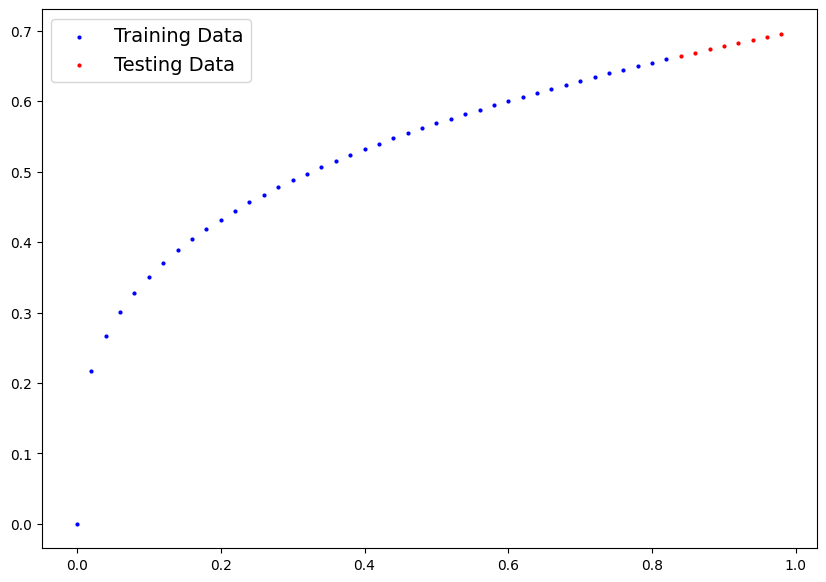

In [6]:
plot_predictions()

## Build model
Pytorch model

In [7]:
# Create a linear regression model class
class LinearRegressionModel(nn.Module): # everythin in pytorch inherits from nn.Module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,requires_grad=True, dtype=torch.float))

  # forward propogation
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x ** self.bias # my own formula it should be linear regression


### PyTorch model building essentiaals

* torch.nn - all the buildings for computation graphs (a neural netwoork can be computational graph)
* torch.nn.Parameter - what param should out model try and learn to tweak it exactly like out data output, torch.nn will set these for us in future
* torch.nn.Module - the base class for all nn module, if subclass, should create your own forward method
* torch.optim - model optimization
* def forward() - All nn module require you to overwrite this function which define what happens during forward propogation

### Checking the content of pytorch model

We can check whats inside out param using .parameters()

In [8]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
# List the named params
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`
To check our models predictive power, lets use it on y_test based on X_test

In [10]:
# Make Prediction With Model|
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([0.3292, 0.3302, 0.3312, 0.3322, 0.3331, 0.3340, 0.3349, 0.3358])

In [11]:
y_test

tensor([0.6643, 0.6690, 0.6737, 0.6782, 0.6827, 0.6871, 0.6915, 0.6958])

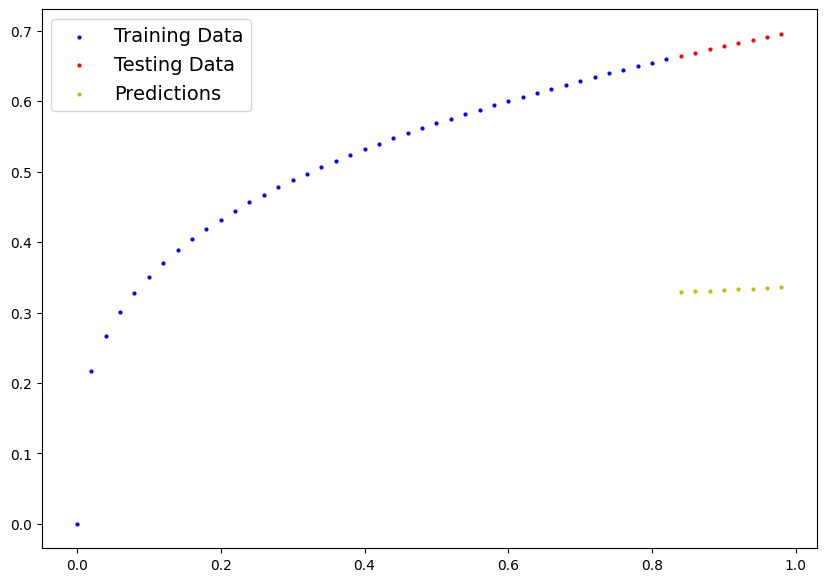

In [12]:
plot_predictions(predictions=y_preds)

## 3. Train model

The whole idea of training is for a model to move from some *unknown* params to *known* params

using a loss function we can figure out how bad the model is performing

Things we need to train:
* **Loss Function**: func to measuree how wrong your model is
* **Optimizer**: Adjusting and optimizing the flow of making the model better

In [13]:
# Setup a loss fucntion
loss_fn = nn.L1Loss()

# Setup an optimiser
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

### Building a training and testing loop in pytorch

0. Loop through the data
1. forward pass (this involves tdata moving forward)
2. Calculate the loss (compare forwaawrd pass pred to ground truth labels)
3. Optimize zero grad
4. Loss backward - move backward in the network to calculate the gradient i.e. the slope of change
5. optimizer step - use the optimizer to adjust out models param and improve

In [14]:
epochs = 300

# Tracking experiments
epoch_count = []
loss_values = []
test_loss_values = []

#0 Loop
for epoch in range(epochs):
  model_0.train() # train model sets the parqams to require grad

  #1 Forward pass
  y_pred = model_0(X_train)

  #2 Loss Calculation
  loss = loss_fn(y_pred, y_train)

  #3 Optimizer zero grad
  optimizer.zero_grad()

  #4 Loss backward propogation
  loss.backward()

  #5 Optimizer step (Gradient Descend)
  optimizer.step() # by default how the optimizer changes will acuulumate through the loop. we have to zero them above at step 3 for the next iteration of the training epoch

  model_0.eval() # used to implement dropout and batch normalization techiques
  with torch.inference_mode(): # turns off fradient tracking and couple more calculation and tracking behind the scenes
    # 1. do forward pass
    test_pred = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)
    if epoch % 10 == 0:
      epoch_count.append(epoch)
      loss_values.append(loss)
      test_loss_values.append(test_loss)
      print(f"Epoch: {epoch} | Loss: {loss}")

print(model_0.state_dict())


Epoch: 0 | Loss: 0.21579769253730774
Epoch: 10 | Loss: 0.14118973910808563
Epoch: 20 | Loss: 0.09329592436552048
Epoch: 30 | Loss: 0.07210128009319305
Epoch: 40 | Loss: 0.06149674206972122
Epoch: 50 | Loss: 0.05371183529496193
Epoch: 60 | Loss: 0.04665340855717659
Epoch: 70 | Loss: 0.0399596244096756
Epoch: 80 | Loss: 0.03344271332025528
Epoch: 90 | Loss: 0.027186961844563484
Epoch: 100 | Loss: 0.021148284897208214
Epoch: 110 | Loss: 0.01530987024307251
Epoch: 120 | Loss: 0.009647427126765251
Epoch: 130 | Loss: 0.0041857510805130005
Epoch: 140 | Loss: 0.006259814836084843
Epoch: 150 | Loss: 0.006560485810041428
Epoch: 160 | Loss: 0.006160298828035593
Epoch: 170 | Loss: 0.00646052835509181
Epoch: 180 | Loss: 0.006760028190910816
Epoch: 190 | Loss: 0.0070590367540717125
Epoch: 200 | Loss: 0.0037966694217175245
Epoch: 210 | Loss: 0.003484566928818822
Epoch: 220 | Loss: 0.0031730900518596172
Epoch: 230 | Loss: 0.002862192690372467
Epoch: 240 | Loss: 0.0025519500486552715
Epoch: 250 | Loss:

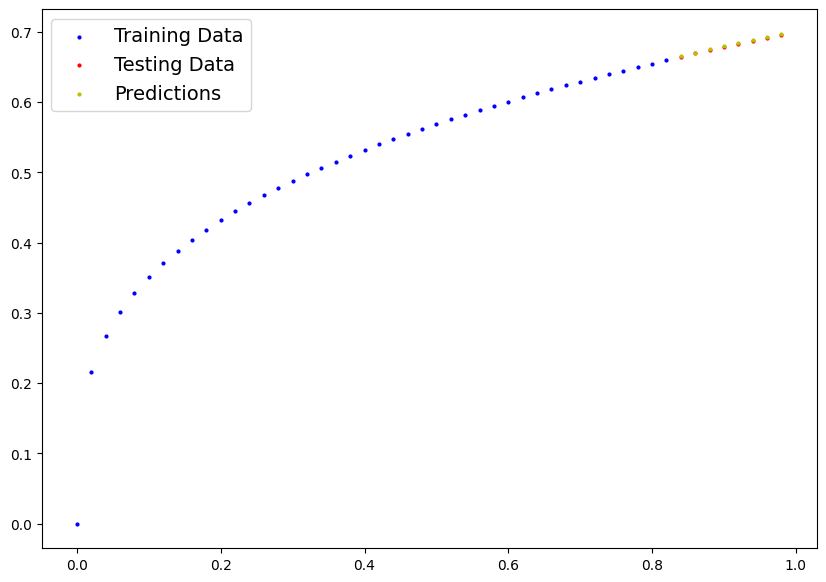

In [15]:
with torch.inference_mode():
  y_preds = model_0(X_test)

plot_predictions(predictions=y_preds)

/tmp/ipython-input-980891754.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train Loss")


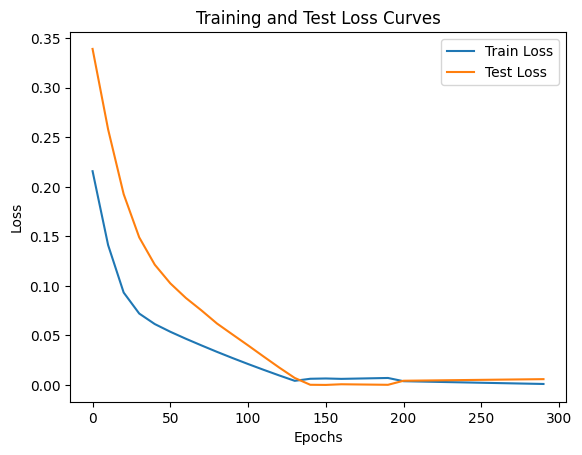

In [16]:
#Plot the loss curves
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train Loss")
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).numpy()), label="Test Loss")
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

## Saving models param in pytorch
Three main methods to svae and load models
1. `torch.save()` - Allows you to save a PyTorch object in pythons pickle format (save it in a very compressed format)
2. `torch.load()` - Allows you to load a saved PyTorch Object
3. `torch.nn.Module.load_state_dict()` - This allows to load a model's saved state dictionary

In [17]:
# Saving a pytorch model
from pathlib import Path

# Create Model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create a model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [18]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Nov  6 07:25 01_pytorch_workflow_model_0.pth


In [19]:
## Loading a PyTorch model
model_1 = LinearRegressionModel()
model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))
model_1.state_dict()

OrderedDict([('weights', tensor([0.7013])), ('bias', tensor([0.3004]))])

In [20]:
# Make some predictions
model_1.eval()
with torch.inference_mode():
  model_preds = model_1(X_test)

model_preds

tensor([0.6655, 0.6702, 0.6748, 0.6794, 0.6839, 0.6884, 0.6927, 0.6970])

In [21]:
# Compare loaded model preds with original model preds
y_preds == model_preds

tensor([True, True, True, True, True, True, True, True])

## 6. Putting it all together, lets practice

In [22]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device {device}")

Device cpu


In [24]:
## Data
w = 0.85
b = 0.34

X = torch.arange(5,25,0.34).unsqueeze(dim=1)
y = (w * X  + b)
print(X[:10], y[:10])
data_size = len(X)
def return_percentage_data(percentage, data_size=data_size):
  return int(data_size * percentage)
X_train = torch.cat((X[:return_percentage_data(0.3)], X[return_percentage_data(0.5):]))
y_train = torch.cat((y[:return_percentage_data(0.3)], y[return_percentage_data(0.5):]))
X_test = X[return_percentage_data(0.3):return_percentage_data(0.5)]
y_test = y[return_percentage_data(0.3):return_percentage_data(0.5)]
len(X_train), len(y_train), len(X_test), len(y_test)

tensor([[5.0000],
        [5.3400],
        [5.6800],
        [6.0200],
        [6.3600],
        [6.7000],
        [7.0400],
        [7.3800],
        [7.7200],
        [8.0600]]) tensor([[4.5900],
        [4.8790],
        [5.1680],
        [5.4570],
        [5.7460],
        [6.0350],
        [6.3240],
        [6.6130],
        [6.9020],
        [7.1910]])


(47, 47, 12, 12)

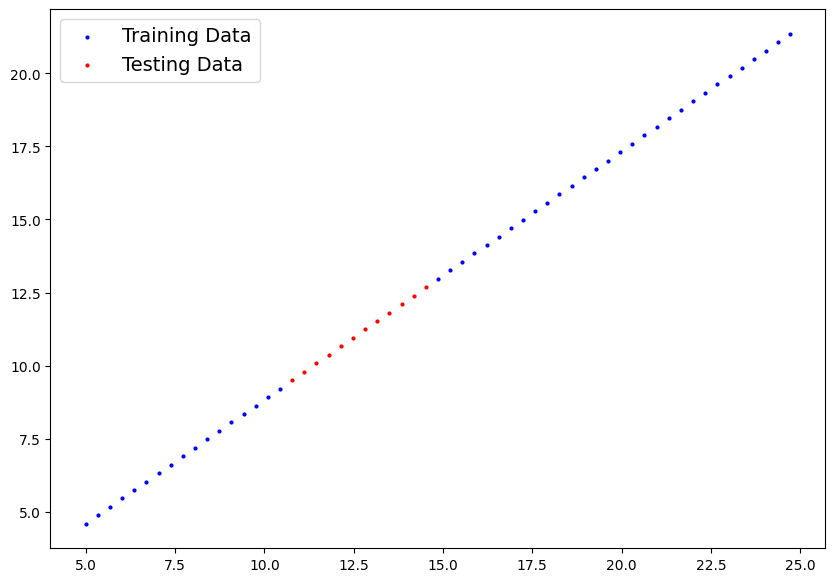

In [25]:
# Visualization

def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None,
                     test=None):
  """
  Plots training data, test data and compares prediction
  """
  plt.figure(figsize=(10,7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
  plt.scatter(test_data, test_labels, c="r", s=4, label="Testing Data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c="y", s=4, label="Predictions")
  if test is not None:
    plt.scatter(test["a"], test["b"], c="g", s=8, label="Test")
  # show legend
  plt.legend(prop={"size":14})

plot_predictions()

In [26]:
# Building a pyTorch model

class Model(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() to create linear layer
    self.linear_layer = nn.Linear(in_features=1, out_features=1) # 1 input x has only 1 output y

  def  forward(self, x:torch.Tensor) ->  torch.Tensor:
    return self.linear_layer(x)

In [27]:
torch.manual_seed(42)
model_1 = Model()
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [28]:
# Set the model to use the traget device
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

In [29]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(lr=0.01, params=model_1.parameters())


In [30]:
torch.manual_seed(42)

epochs = 200

# put tensor on target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

epoch_values = []
train_loss_values = []
test_loss_values = []
for e in range(epochs):
  model_1.train()

  y_pred = model_1(X_train)

  loss = loss_fn(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    y_preds = model_1(X_test)
    test_loss = loss_fn(y_preds, y_test)

  if e % 10 == 0:
    print(f"Epoch: {e} | Loss: {loss} | Test Loss: {test_loss}")
    epoch_values.append(e)
    train_loss_values.append(loss)
    test_loss_values.append(test_loss)

Epoch: 0 | Loss: 0.8324671983718872 | Test Loss: 0.45458054542541504
Epoch: 10 | Loss: 0.31641241908073425 | Test Loss: 0.320904016494751
Epoch: 20 | Loss: 0.20344538986682892 | Test Loss: 0.09419631958007812
Epoch: 30 | Loss: 0.14659419655799866 | Test Loss: 0.11626061052083969
Epoch: 40 | Loss: 0.13949252665042877 | Test Loss: 0.17275412380695343
Epoch: 50 | Loss: 0.11649780720472336 | Test Loss: 0.14735515415668488
Epoch: 60 | Loss: 0.09920229017734528 | Test Loss: 0.11776677519083023
Epoch: 70 | Loss: 0.0816066786646843 | Test Loss: 0.09759696573019028
Epoch: 80 | Loss: 0.0631939172744751 | Test Loss: 0.07037290185689926
Epoch: 90 | Loss: 0.04362765699625015 | Test Loss: 0.04649273678660393
Epoch: 100 | Loss: 0.023309586569666862 | Test Loss: 0.026214122772216797
Epoch: 110 | Loss: 0.021496133878827095 | Test Loss: 0.013305346481502056
Epoch: 120 | Loss: 0.018212510272860527 | Test Loss: 0.03356941416859627
Epoch: 130 | Loss: 0.01022588461637497 | Test Loss: 0.00943136215209961
Epo

In [31]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.8504]])),
             ('linear_layer.bias', tensor([0.3360]))])

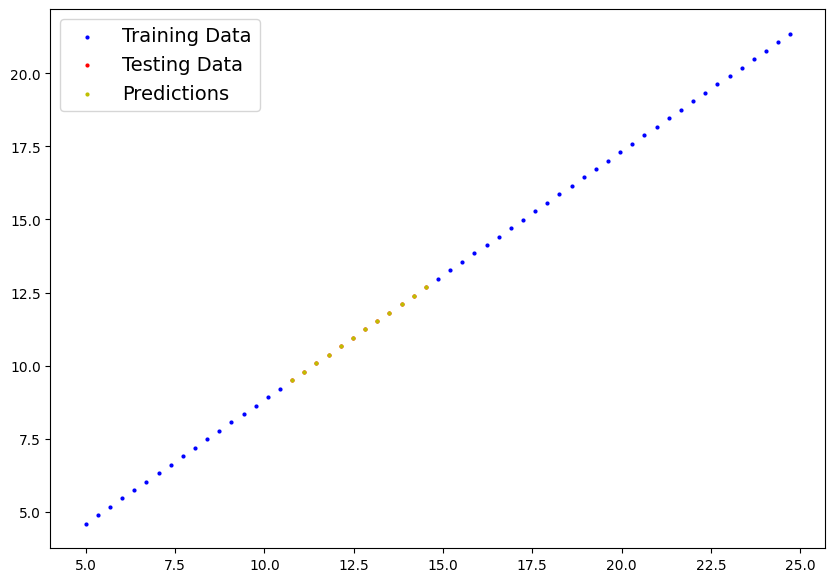

In [32]:
model_1.eval()
with torch.inference_mode():
  y_preds = model_1(X_test)

plot_predictions(predictions=y_preds.to("cpu"))

Input: tensor([[28.]]) | Output: tensor([[24.1480]])


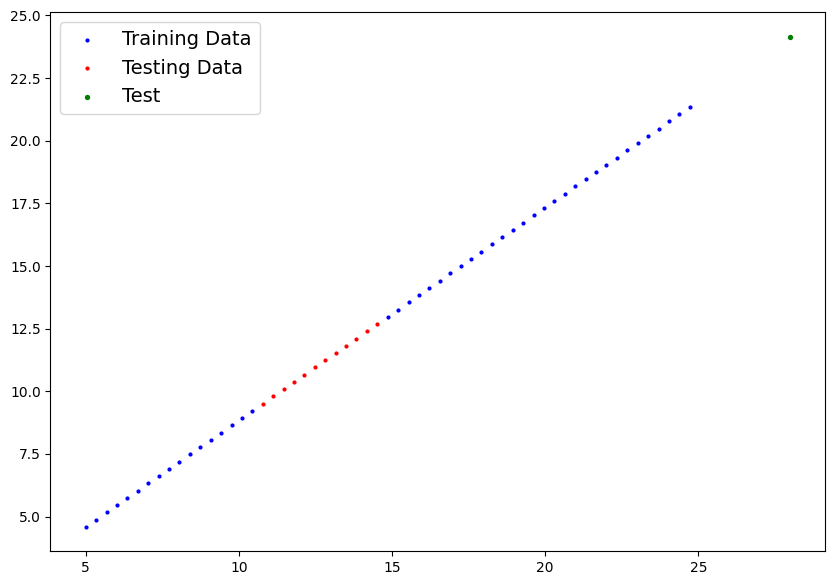

In [33]:
input_number = 28.
input_tensor = torch.tensor([[input_number]]).to(device) # or simply .cuda()
model_1.eval()
with torch.inference_mode():
  a = model_1(input_tensor).to("cpu")
  plot_predictions(test={"a":input_number, "b":a})
  print(f"Input: {input_tensor} | Output: {a}")

In [34]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [35]:
loaded_model_1 = Model()
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model_1.to(device)
loaded_model_1.state_dict() == model_1.state_dict()

True

In [36]:
loaded_model_1.eval()
with torch.inference_mode():
  loaded_y_preds = loaded_model_1(X_test)

loaded_y_preds == y_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# Exercises and Extra

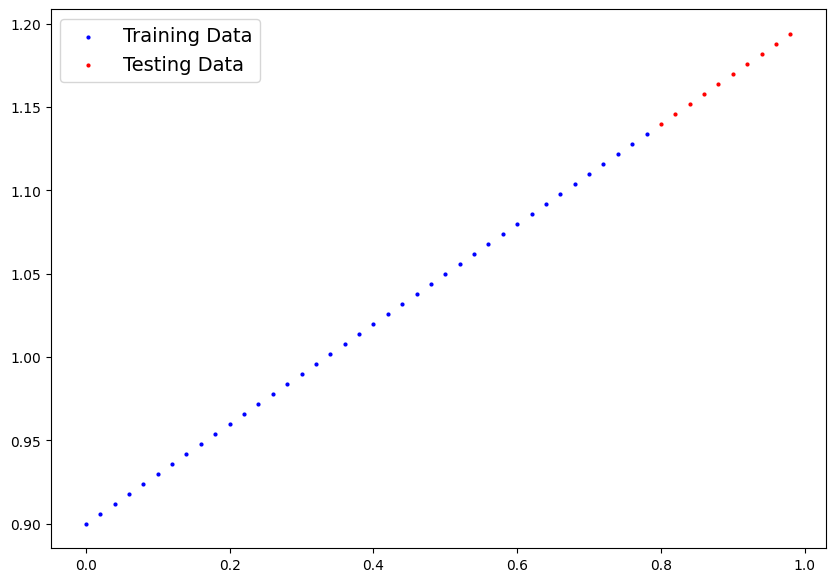

In [55]:
w = 0.3
b = 0.9
device = "cuda" if torch.cuda.is_available() else "cpu"
start = 0
end = 1
step=0.02

X = torch.arange(start,end,step).to(device)
y = w * X + b

X_train, y_train = X[:40], y[:40]
X_test, y_test = X[40:], y[40:]
plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test)

In [56]:
class EModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(data=torch.randn(1,requires_grad=True))
    self.bias = nn.Parameter(data=torch.randn(1,requires_grad=True))

  def forward(self,x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [57]:
emodel = EModel().to(device)
emodel.state_dict()

OrderedDict([('weights', tensor([0.3930])), ('bias', tensor([0.4327]))])

In [58]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=emodel.parameters(),lr=0.01)

In [59]:
epoch = 300

for e in range(epoch):
  emodel.train()

  y_pred = emodel(X_train)

  train_loss = loss_fn(y_pred,y_train)

  optimizer.zero_grad()

  train_loss.backward()

  optimizer.step()

  emodel.eval()
  with torch.inference_mode():
    y_pred = emodel(X_test)

    test_loss = loss_fn(y_pred, y_test)

    if e % 20 == 0:
      print(f"Epoch {e}: Loss = {test_loss}")

Epoch 0: Loss = 0.371030330657959
Epoch 20: Loss = 0.1016106829047203
Epoch 40: Loss = 0.08848530054092407
Epoch 60: Loss = 0.08997758477926254
Epoch 80: Loss = 0.07343286275863647
Epoch 100: Loss = 0.05757499858736992
Epoch 120: Loss = 0.04171711206436157
Epoch 140: Loss = 0.0251724012196064
Epoch 160: Loss = 0.009314512833952904
Epoch 180: Loss = 0.010082697495818138
Epoch 200: Loss = 0.010082697495818138
Epoch 220: Loss = 0.010082697495818138
Epoch 240: Loss = 0.010082697495818138
Epoch 260: Loss = 0.010082697495818138
Epoch 280: Loss = 0.010082697495818138


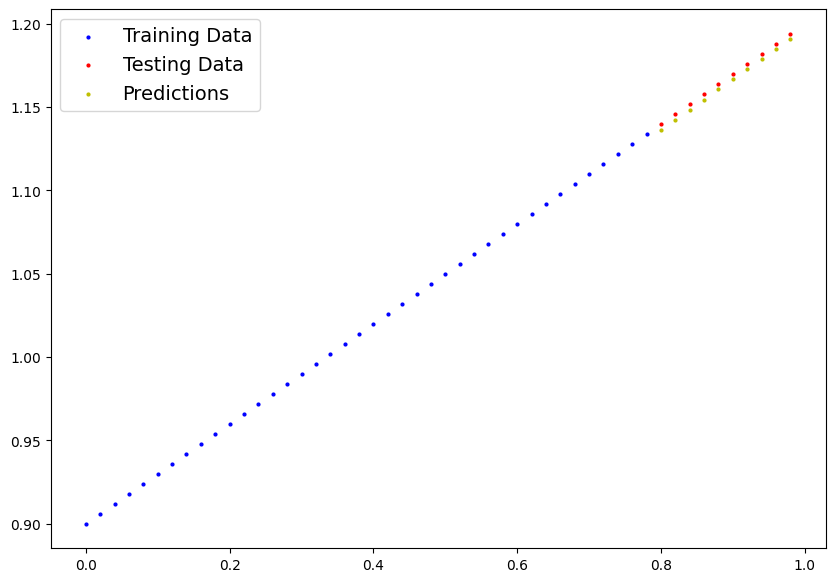

In [62]:
emodel.eval()
with torch.inference_mode():
  y_pred = emodel(X_test)

plot_predictions(train_data = X_train,
                 train_labels = y_train,
                 test_data = X_test,
                 test_labels = y_test,
                 predictions = y_pred)

In [63]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_exercise.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving the emodel to {MODEL_SAVE_PATH}")
torch.save(obj=emodel.state_dict(),f = MODEL_SAVE_PATH)

Saving the emodel to models/01_pytorch_exercise.pth


In [64]:
emodel_loaded = EModel()
emodel_loaded.load_state_dict(torch.load(MODEL_SAVE_PATH))
emodel_loaded.state_dict(), emodel.state_dict()

(OrderedDict([('weights', tensor([0.3033])), ('bias', tensor([0.8937]))]),
 OrderedDict([('weights', tensor([0.3033])), ('bias', tensor([0.8937]))]))